# CIFAR-10 Residual CNN 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

### 1. Load & Preprocess Data


In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

### 2. Data Augmentation


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

### 3. Residual Block 


In [ ]:
def residual_block(x, filters, downsample=False):
    shortcut = x
    stride = 2 if downsample else 1

    x = layers.Conv2D(filters, 3, strides=stride,
                      padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3,
                      padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride,
                                 use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

### 4. Build Model


In [ ]:
def build_resnet_cifar10():
    inputs = layers.Input(shape=(32, 32, 3))

    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)

    x = residual_block(x, 256, downsample=True)
    x = residual_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    return models.Model(inputs, outputs)

model = build_resnet_cifar10()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 32, 32, 64)   1728        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 32, 32, 64)  256         ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 re_lu (ReLU)                   (None, 32, 32, 64)   0           ['batch_normalization[0][0]']

### 5. Compile


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### 6. Callbacks 


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_cifar10_resnet.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks = [checkpoint, reduce_lr, early_stop]

### 7. Train


In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
782/782 [==============================] - ETA: 0s - loss: 1.3622 - accuracy: 0.5050
Epoch 1: val_loss improved from inf to 4.05628, saving model to best_cifar10_resnet.h5
782/782 [==============================] - 83s 94ms/step - loss: 1.3622 - accuracy: 0.5050 - val_loss: 4.0563 - val_accuracy: 0.2649 - lr: 0.0010
Epoch 2/100
782/782 [==============================] - ETA: 0s - loss: 0.9010 - accuracy: 0.6828
Epoch 2: val_loss improved from 4.05628 to 1.54295, saving model to best_cifar10_resnet.h5
782/782 [==============================] - 72s 92ms/step - loss: 0.9010 - accuracy: 0.6828 - val_loss: 1.5429 - val_accuracy: 0.5517 - lr: 0.0010
Epoch 3/100
782/782 [==============================] - ETA: 0s - loss: 0.7331 - accuracy: 0.7432
Epoch 3: val_loss did not improve from 1.54295
782/782 [==============================] - 72s 92ms/step - loss: 0.7331 - accuracy: 0.7432 - val_loss: 1.5750 - val_accuracy: 0.5333 - lr: 0.0010
Epoch 4/100
782/782 [=========================

### 8. Load Best Model & Evaluate


In [ ]:
best_model = tf.keras.models.load_model("best_cifar10_resnet.h5")
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)

print(f"\nBest Model Test Accuracy: {test_acc:.4f}")


Best Model Test Accuracy: 0.9177


### 9. Summary

Test Accuracy: 0.9177

Confusion Matrix:



,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
airplane,934,2,11,8,3,0,0,7,22,13
automobile,2,979,0,0,1,1,0,0,2,15
bird,18,1,919,15,14,5,17,6,2,3
cat,10,2,37,807,32,56,33,16,3,4
deer,5,2,29,13,916,6,9,19,1,0
dog,5,1,30,80,16,825,16,26,0,1
frog,4,1,25,7,5,0,954,2,1,1
horse,6,0,8,11,8,8,3,951,1,4
ship,23,6,2,2,0,0,1,0,953,13
truck,12,36,2,0,0,0,0,2,9,939



Per-Class Performance:



,Class,Total,Correct,Incorrect,Accuracy (%)
0,airplane,1000,934,66,93.4
1,automobile,1000,979,21,97.9
2,bird,1000,919,81,91.9
3,cat,1000,807,193,80.7
4,deer,1000,916,84,91.6
5,dog,1000,825,175,82.5
6,frog,1000,954,46,95.4
7,horse,1000,951,49,95.1
8,ship,1000,953,47,95.3
9,truck,1000,939,61,93.9



Classification Report:



,precision,recall,f1-score,support
airplane,0.916585,0.9340,0.925211,1000.0000
automobile,0.950485,0.9790,0.964532,1000.0000
bird,0.864534,0.9190,0.890936,1000.0000
cat,0.855779,0.8070,0.830674,1000.0000
deer,0.920603,0.9160,0.918296,1000.0000
dog,0.915649,0.8250,0.867964,1000.0000
frog,0.923524,0.9540,0.938515,1000.0000
horse,0.924198,0.9510,0.937408,1000.0000
ship,0.958753,0.9530,0.955868,1000.0000
truck,0.945619,0.9390,0.942298,1000.0000


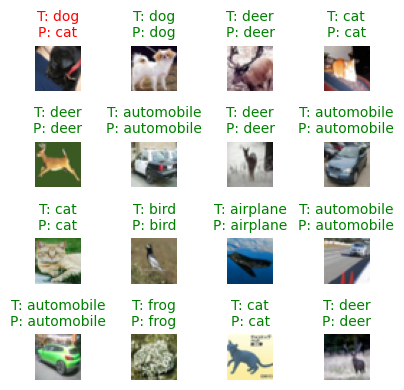

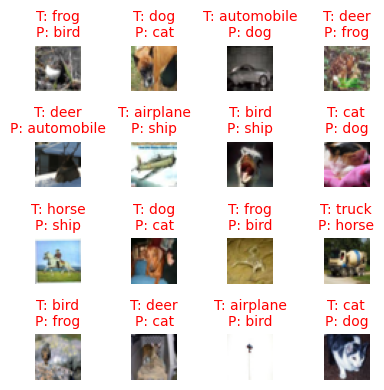

In [ ]:
from model_check import (
    full_classification_report,
    show_predictions_grid,
    show_misclassified_grid
)

cm_df, per_class_df, clf_report_df = full_classification_report(best_model, X_test, y_test)

show_predictions_grid(best_model, X_test, y_test, n=4)

show_misclassified_grid(best_model, X_test, y_test, n=4)